In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("loan_approval_dataset.csv",skipinitialspace=True)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [4]:
columns = ['education','self_employed','load_status']

df['loan_status'].value_counts().keys()

Index(['Approved', 'Rejected'], dtype='object', name='loan_status')

In [5]:
df['cibil_score'].mean()

599.9360505973295

In [6]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [7]:
bussiness_man = df[df['self_employed'] == "Yes"]
salaried_person = df[df['self_employed'] == "No"]

In [8]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [9]:
bussiness_man['loan_status'].value_counts()

loan_status
Approved    1338
Rejected     812
Name: count, dtype: int64

In [10]:
salaried_person['loan_status'].value_counts()

loan_status
Approved    1318
Rejected     801
Name: count, dtype: int64

In [11]:
score = df[df['cibil_score'] <= df['cibil_score'].mean()]['loan_status'].value_counts()
score

loan_status
Rejected    1602
Approved     531
Name: count, dtype: int64

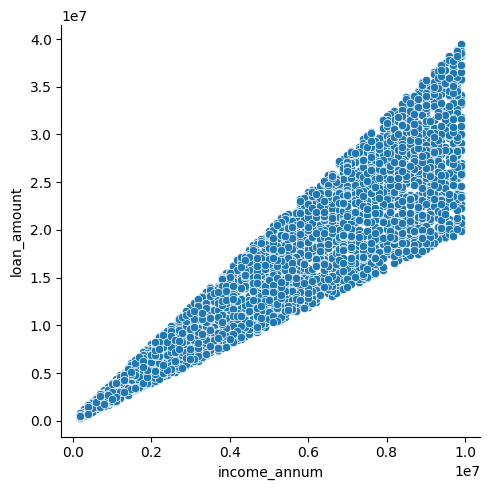

In [12]:
sns.relplot(x='income_annum',y='loan_amount',data=df)
plt.show()

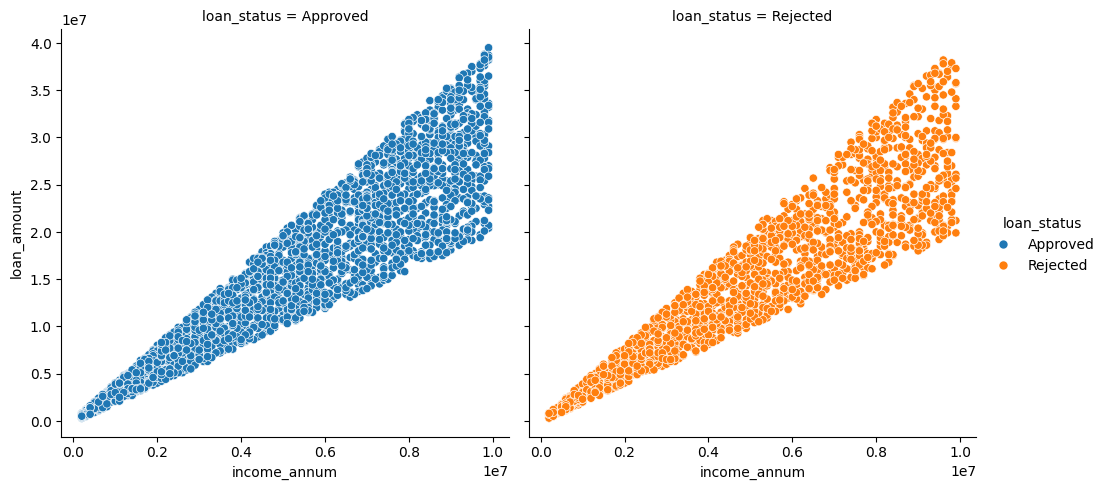

In [13]:
sns.relplot(x='income_annum',y='loan_amount',data=df,hue='loan_status',col='loan_status')
plt.show()

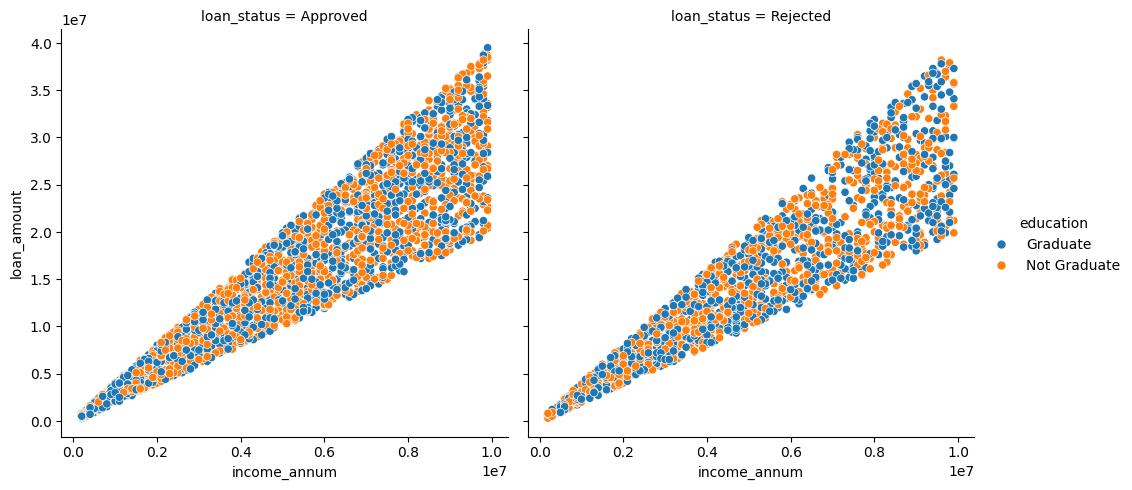

In [14]:
sns.relplot(x='income_annum',y='loan_amount',data=df,hue='education',col='loan_status')
plt.show()

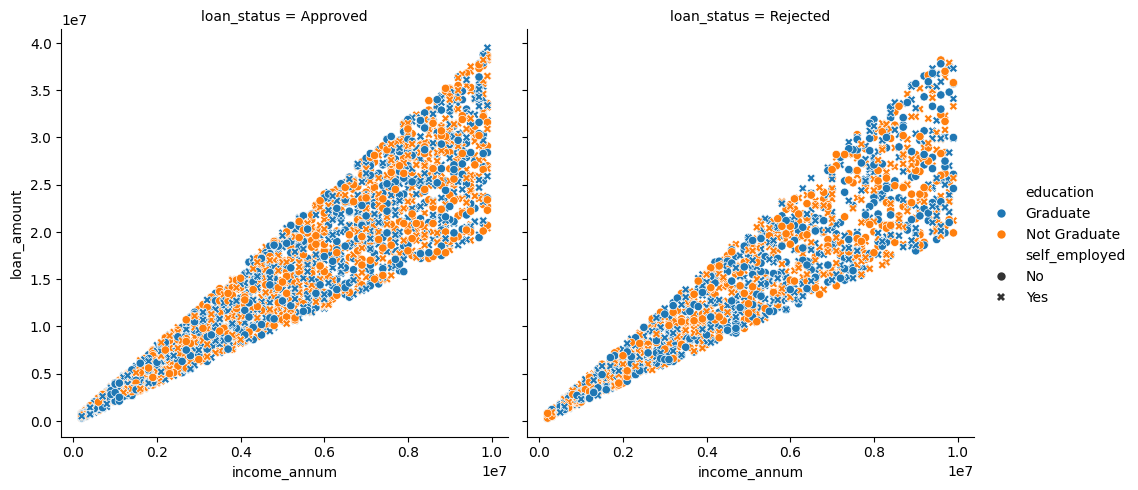

In [15]:
sns.relplot(x='income_annum',y='loan_amount',data=df,hue='education',style='self_employed',col='loan_status')
plt.show()

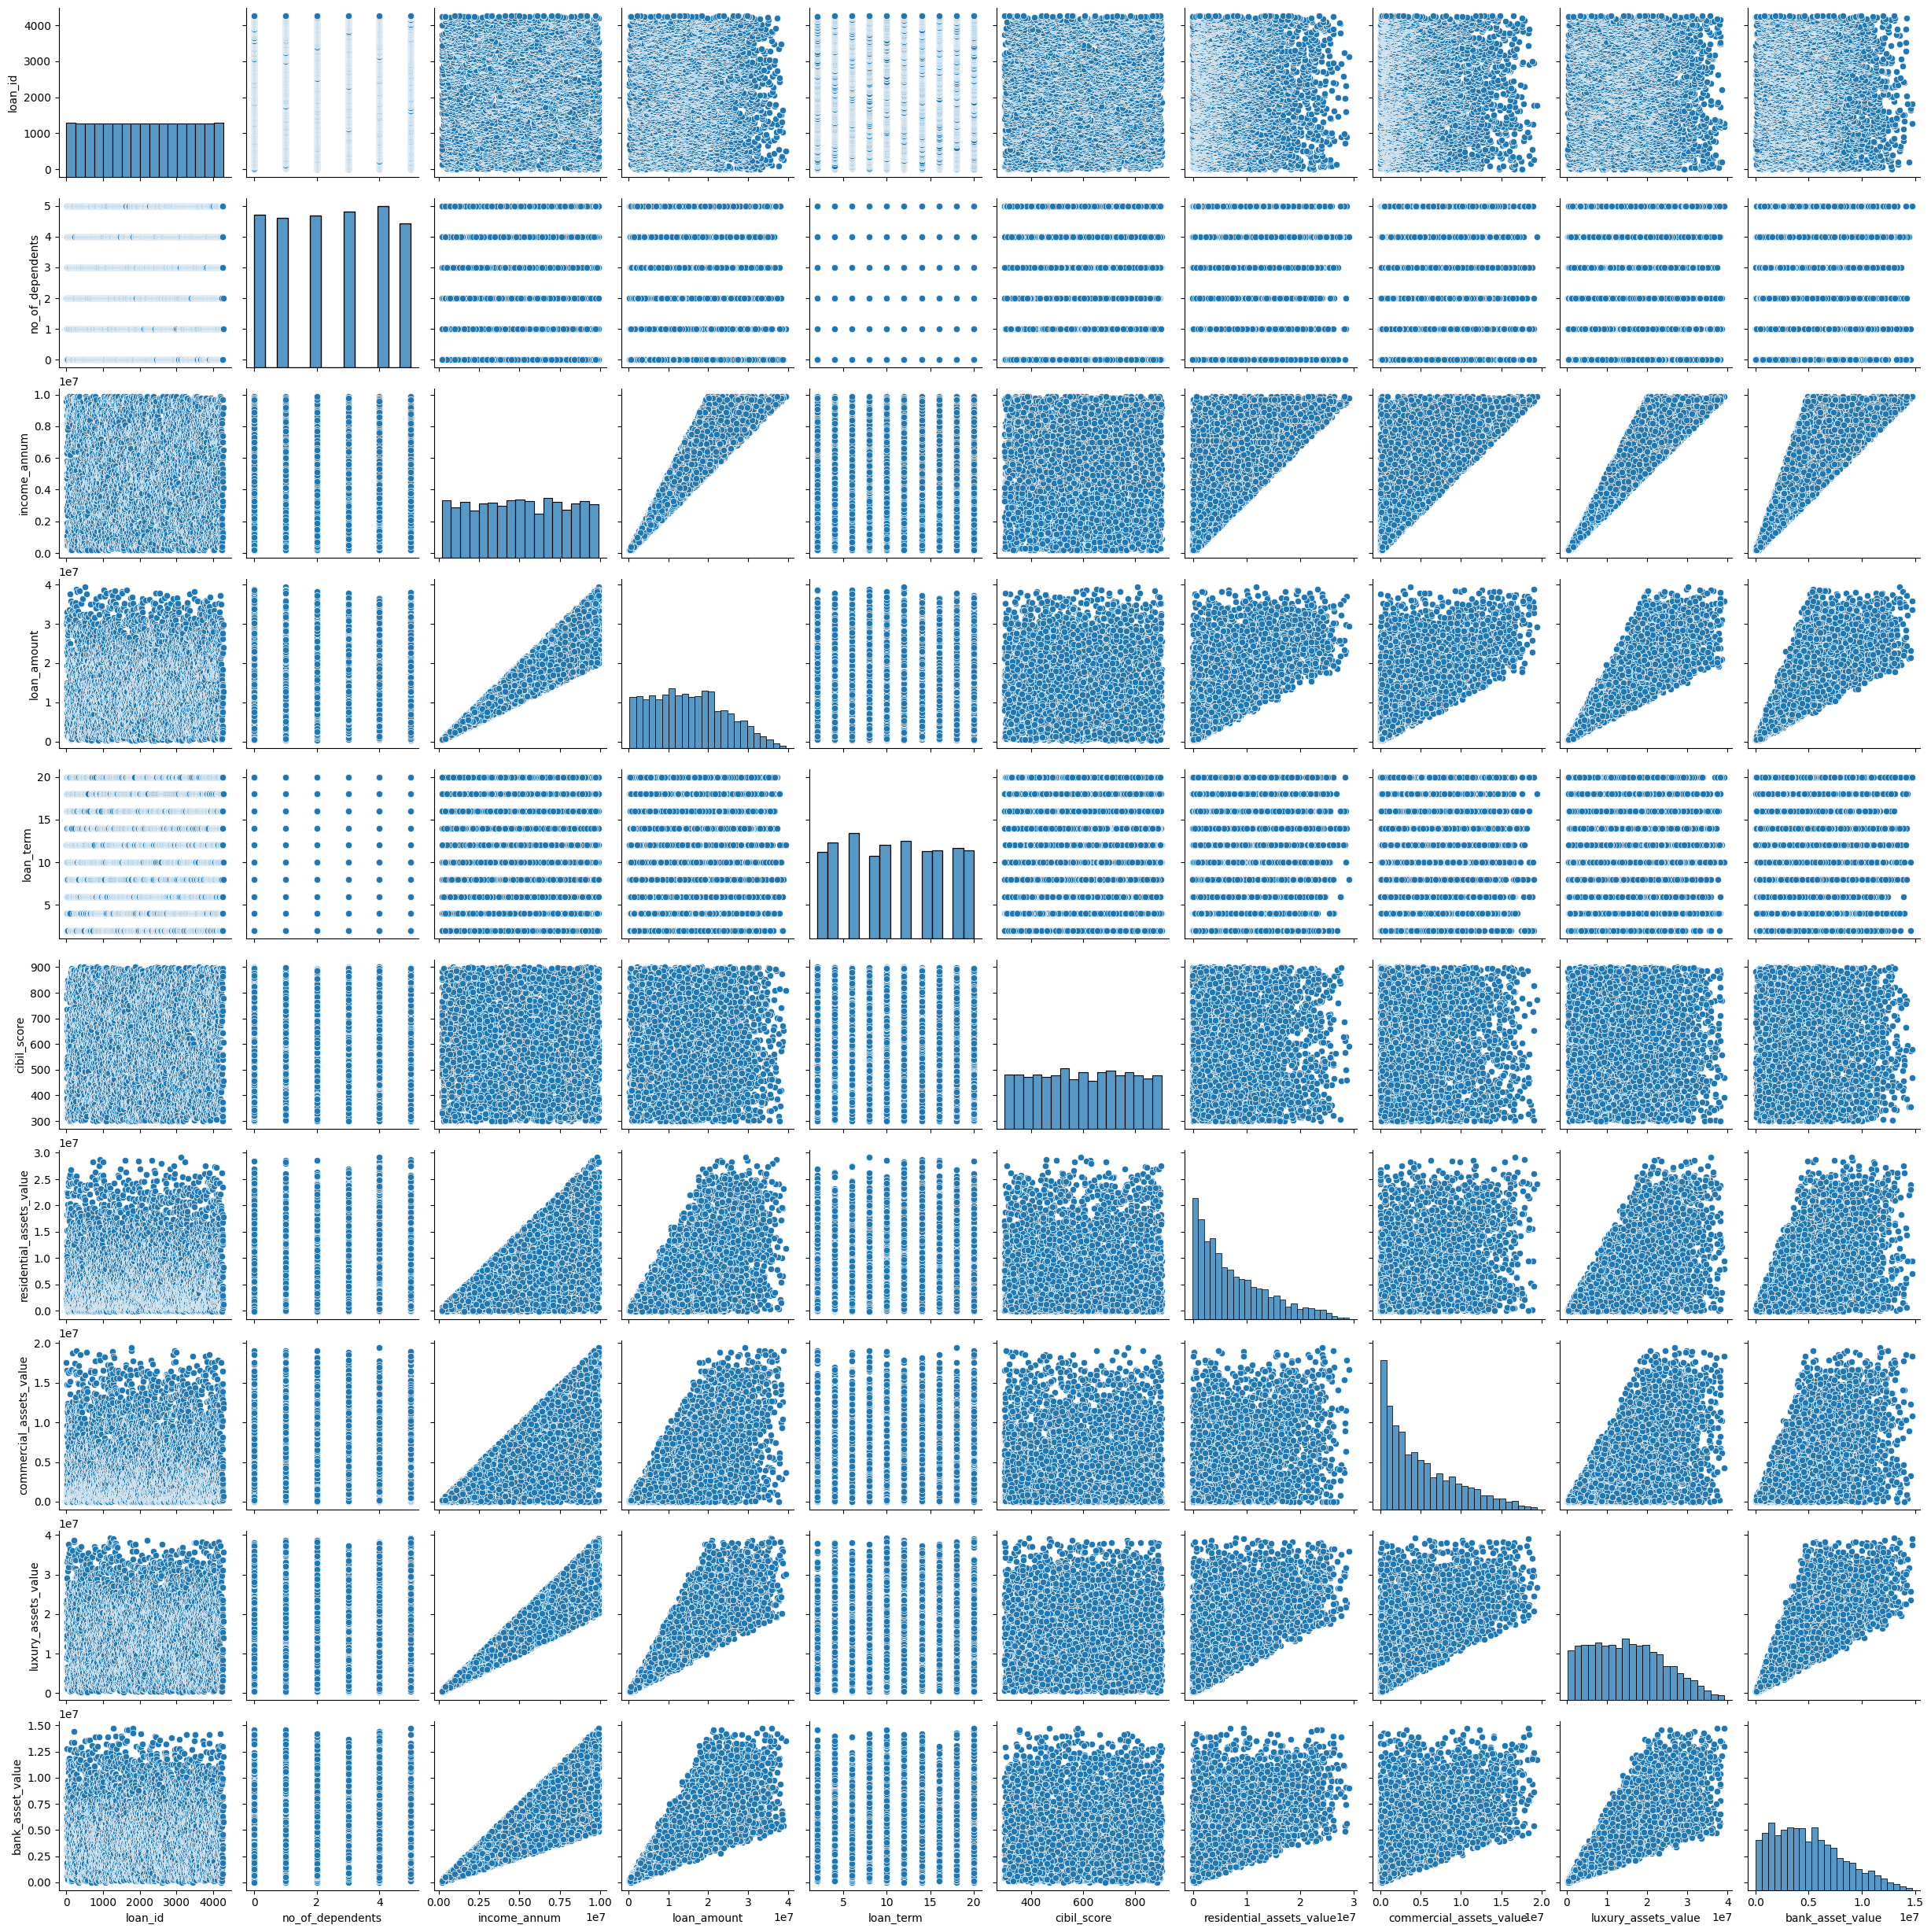

In [16]:
sns.pairplot(df)

In [17]:
df2 = pd.get_dummies(df,drop_first='if_binary').astype(int)
df2.head()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Not Graduate,self_employed_Yes,loan_status_Rejected
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,1
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1,1


In [18]:
df2.dtypes

loan_id                     int32
no_of_dependents            int32
income_annum                int32
loan_amount                 int32
loan_term                   int32
cibil_score                 int32
residential_assets_value    int32
commercial_assets_value     int32
luxury_assets_value         int32
bank_asset_value            int32
education_Not Graduate      int32
self_employed_Yes           int32
loan_status_Rejected        int32
dtype: object

In [19]:
df2.drop('loan_id',axis=1,inplace=True)

In [20]:
x = df2.drop("loan_status_Rejected",axis=1)
y = df2[['loan_status_Rejected']]

In [21]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_transformed = scaler.fit_transform(x)

In [22]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_transformed,y,test_size=0.15)

In [23]:
# algorithm train or model train
from sklearn.ensemble import RandomForestClassifier
rdf = RandomForestClassifier()
rdf.fit(x_train,y_train)
print(rdf.score(x_train,y_train)*100)
print(rdf.score(x_test,y_test)*100)

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


100.0
98.75195007800312


In [24]:
x_train.shape

(3628, 11)

binary classification -> sigmoid

multi classification -> softmax

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
Ann_model = Sequential()

Ann_model.add(Dense(units=64,activation='relu',input_dim=11))  # 1 hidden layer add with input layer...
Ann_model.add(Dense(units=32,activation='relu'))  # 2 hidden layer...
Ann_model.add(Dense(units=16,activation='relu')) # 3 hidden layer...

Ann_model.add(Dense(units=1,activation='sigmoid'))  # output layer (binary classification)

Ann_model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

Ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = Ann_model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7143 - loss: 0.5503 - val_accuracy: 0.9126 - val_loss: 0.2388
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9256 - loss: 0.2188 - val_accuracy: 0.9142 - val_loss: 0.2054
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9325 - loss: 0.1950 - val_accuracy: 0.9204 - val_loss: 0.1939
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9303 - loss: 0.1839 - val_accuracy: 0.9314 - val_loss: 0.1834
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9360 - loss: 0.1729 - val_accuracy: 0.9298 - val_loss: 0.1730
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9472 - loss: 0.1496 - val_accuracy: 0.9345 - val_loss: 0.1666
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9451 - loss: 0.1434 - val_accuracy: 0.9314 - val_loss: 0.1588
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - loss: 0.1272 - val_accuracy: 0.

In [28]:
history_df = pd.DataFrame(history.history,index=range(1,11))
history_df

,accuracy,loss,val_accuracy,val_loss
1,0.811191,0.427828,0.912637,0.238827
2,0.928060,0.210303,0.914197,0.205354
3,0.936053,0.185489,0.920437,0.193944
4,0.937431,0.172392,0.931357,0.183444
5,0.943219,0.158368,0.929797,0.173039
6,0.942944,0.151939,0.934477,0.166594
7,0.947354,0.139947,0.931357,0.158793
8,0.950386,0.132005,0.943838,0.146284
9,0.954520,0.122422,0.940718,0.140956
10,0.957552,0.116014,0.943838,0.135252


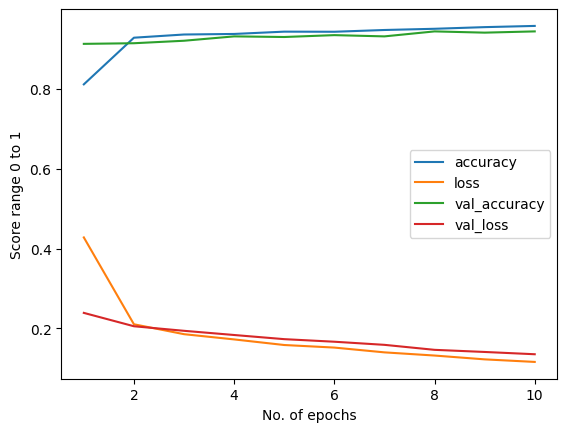

In [29]:
history_df.plot()
plt.xlabel('No. of epochs')
plt.ylabel('Score range 0 to 1')
plt.show()

In [30]:
prediction = Ann_model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [31]:
prediction.shape , x_test.shape

((641, 1), (641, 11))

In [32]:
(prediction>0.5).astype(int).flatten()


# if prob > 0.5:
#     print(1)
# else:
#     print(0)

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,

In [34]:
pred = (prediction > 0.5).astype(int).ravel()
pred

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,

In [35]:
y_test['prediction'] = pred

In [36]:
from sklearn.metrics import confusion_matrix,classification_report

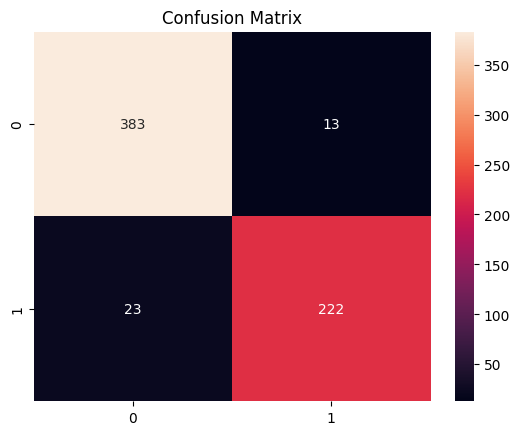

In [37]:
matrix = confusion_matrix(y_test['loan_status_Rejected'],y_test['prediction'])

sns.heatmap(matrix,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [38]:
print(classification_report(y_test['loan_status_Rejected'],y_test['prediction']))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       396
           1       0.94      0.91      0.93       245

    accuracy                           0.94       641
   macro avg       0.94      0.94      0.94       641
weighted avg       0.94      0.94      0.94       641



In [39]:
import os
os.makedirs('models',exist_ok=True)
Ann_model.save('./models/ann_model.h5')    # .h5 tensorflow save  , .pt pytorch

In [42]:
# to load the tensorflow model or objects...
from tensorflow.keras.models import load_model
model_loaded = load_model('./models/ann_model.h5')
model_loaded

<Sequential name=sequential, built=True>